In [1]:
import tkinter as tk
from tkinter import filedialog
import hyperspy.api as hs

In [65]:
# Create a function to select a file
def load_file():
    root = tk.Tk()
    root.withdraw()  # Hide the root window

    file_path = filedialog.askopenfilename(
        title="Select a .hspy file",
        filetypes=[("Hyperspy Files", "*.hspy"), ("All Files", "*.*")]
    )

    if file_path:  # If a file is selected
        print("Selected file:", file_path)
        data = hs.load(file_path)
        print(data)
        return data  # Return loaded data

    return None  # If no file is selected

# Load the selected file
data = load_file()


Selected file: C:/Users/b1104371/OneDrive - Universität Salzburg/Research/Electrolyte variation/Charecterizations/TEM/250128_LiS-charged50/PRE_LiS-charged50_0003.prz
<Signal2D, title: PRE_LiS-charged50, dimensions: (|2048, 2048)>


In [ ]:
data.metadata

In [4]:
data = hs.load(r"C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\TEM\250128_LiS-charged50\satDME_charged_50\New folder\PRE_LiS-charged50_0042.hspy")

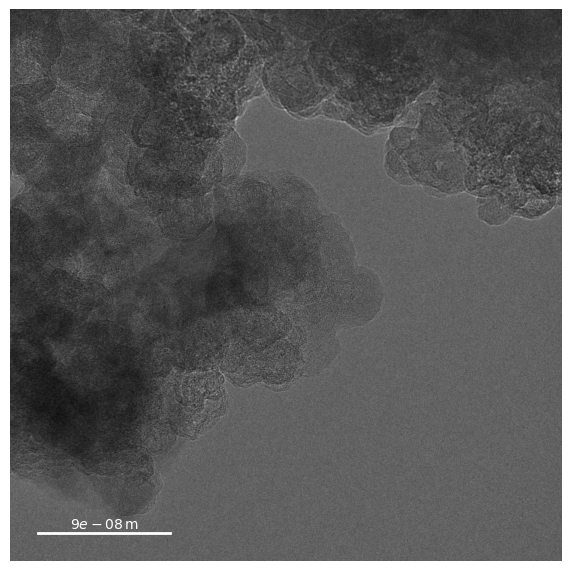

In [66]:
import matplotlib.pyplot as plt
import hyperspy.drawing as hsd
# Add scalebar
scalebar = hsd._widgets.scalebar.ScaleBar(
    ax=ax, 
    units='nm',  # Use 'nm' for nanometers
    pixel_size=data.axes_manager[0].scale, 
    color='white', 
    max_size_ratio=0.2,  # Adjust to control bar length
    lw=2  # Line width of scale bar
)
scalebar.plot_scale()


# Plot the data
data.plot(
    ax=ax,
    colorbar=False,
    scalebar=True,
    axes_ticks=False,
    axes_off=True,
    title=""
)


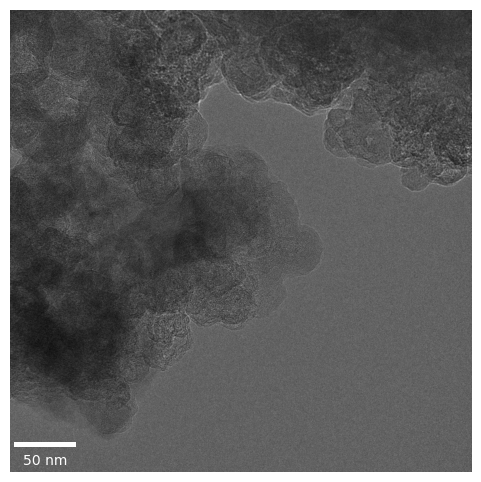

In [70]:
import hyperspy.api as hs
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar


# Get Pixel Size from Metadata (Stored in Meters)
pixel_size_m = data.axes_manager[0].scale  # This is in meters
pixel_size_nm = pixel_size_m * 1e9  # Convert meters to nanometers

# Create Figure & Plot Data
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(data.data, cmap="gray")

# Add Scale Bar with Units in nm (Without Changing Data Scale)
scalebar = ScaleBar(pixel_size_nm, "nm", length_fraction=0.2, color="white", location="lower left",scale_loc=None,  # Removes the background box
    label_loc="bottom",  # Moves label to bottom
    frameon=False)
ax.add_artist(scalebar)

# Remove Axes Ticks & Frame
ax.set_xticks([])
ax.set_yticks([])
ax.set_frame_on(False)

# Show Plot with Scale Bar in nm
plt.show()


In [49]:
import numpy as np

# Normalize data to range [0, 255] for better visibility
data_norm = (data.data - np.min(data.data)) / (np.max(data.data) - np.min(data.data))
data_norm = (data_norm * 255).astype(np.uint8)

import tifffile
tifffile.imwrite("test_normalized1.tiff", data_norm)
